# Short-Term Load Forecasting and Transformer Overload Prevention System

This notebook implements a system to forecast short-term electrical load and detect potential transformer overloads.

**Workflow:**
1.  **Data Loading & Selection**: Identify the most relevant hourly load dataset.
2.  **Preprocessing**: Clean data, handle timestamps, and visualize trends.
3.  **Feature Engineering**: Create time-based and lag features for the model.
4.  **Model Training**: Train an XGBoost model for load forecasting.
5.  **Evaluation**: Assess model performance.
6.  **Overload Prevention**: Simulate a transformer capacity and detect overload risks based on forecasts.

In [8]:
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 34.5 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 35.0 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

# Install xgboost if not present (uncomment if needed)
# !pip install xgboost

## 1. Data Loading and Investigation
We see multiple files in the dataset folder. For this project, we'll focus on the **PJM East (PJME)** region as it provides a robust dataset for demonstrating load forecasting. The file is `PJME_hourly.csv`.

Data Shape: (145366, 2)
              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0


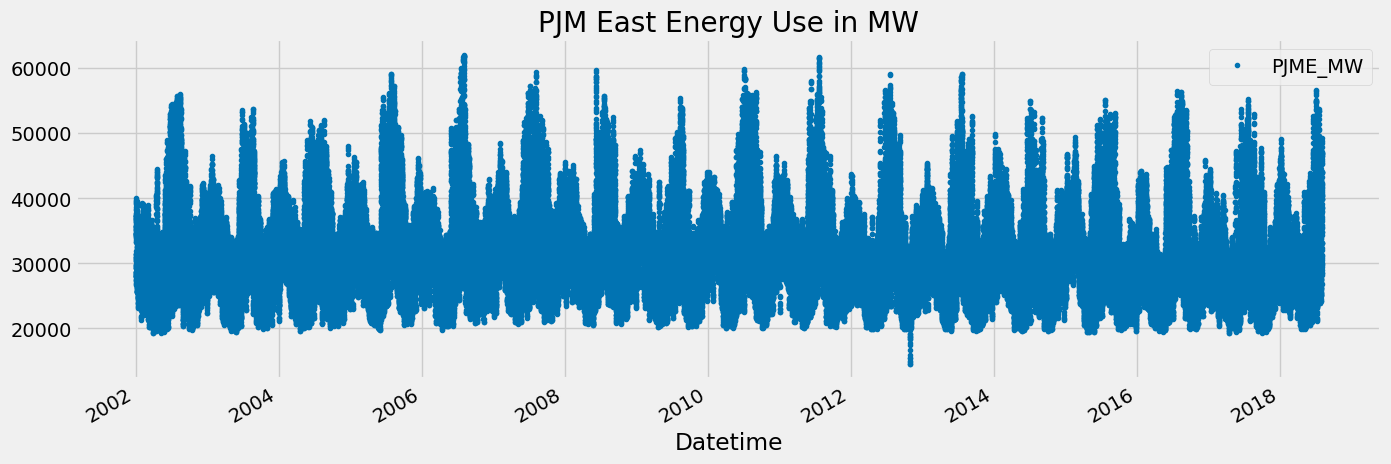

In [11]:
# Define file path
# We are using the PJME_hourly.csv file found in the project data directory
DATA_PATH = 'data/hourly-energy-consumption-v3/PJME_hourly.csv'

# Load the data
df = pd.read_csv(DATA_PATH)
print(f"Data Shape: {df.shape}")
print(df.head())

# Set index to Datetime
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
# Sort index to ensure chronological order
df = df.sort_index()

# Plot the data
df.plot(style='.', figsize=(15, 5), color=sns.color_palette('colorblind')[0], title='PJM East Energy Use in MW')
plt.show()

## 2. Feature Engineering
We will create time-series features based on the datetime index. This allows the model to learn patterns like "daily peak," "weekend lower load," and "seasonal variances."

                     PJME_MW  hour  dayofweek  quarter  month  year  \
Datetime                                                              
2002-01-01 01:00:00  30393.0     1          1        1      1  2002   
2002-01-01 02:00:00  29265.0     2          1        1      1  2002   
2002-01-01 03:00:00  28357.0     3          1        1      1  2002   
2002-01-01 04:00:00  27899.0     4          1        1      1  2002   
2002-01-01 05:00:00  28057.0     5          1        1      1  2002   

                     dayofyear  dayofmonth  weekofyear  
Datetime                                                
2002-01-01 01:00:00          1           1           1  
2002-01-01 02:00:00          1           1           1  
2002-01-01 03:00:00          1           1           1  
2002-01-01 04:00:00          1           1           1  
2002-01-01 05:00:00          1           1           1  


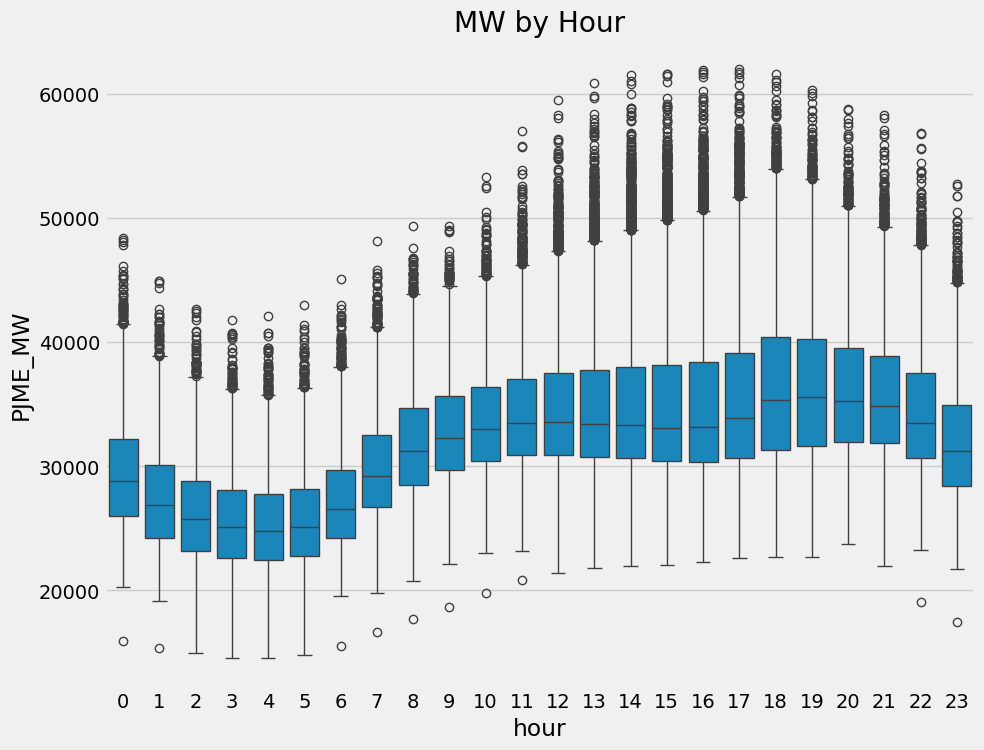

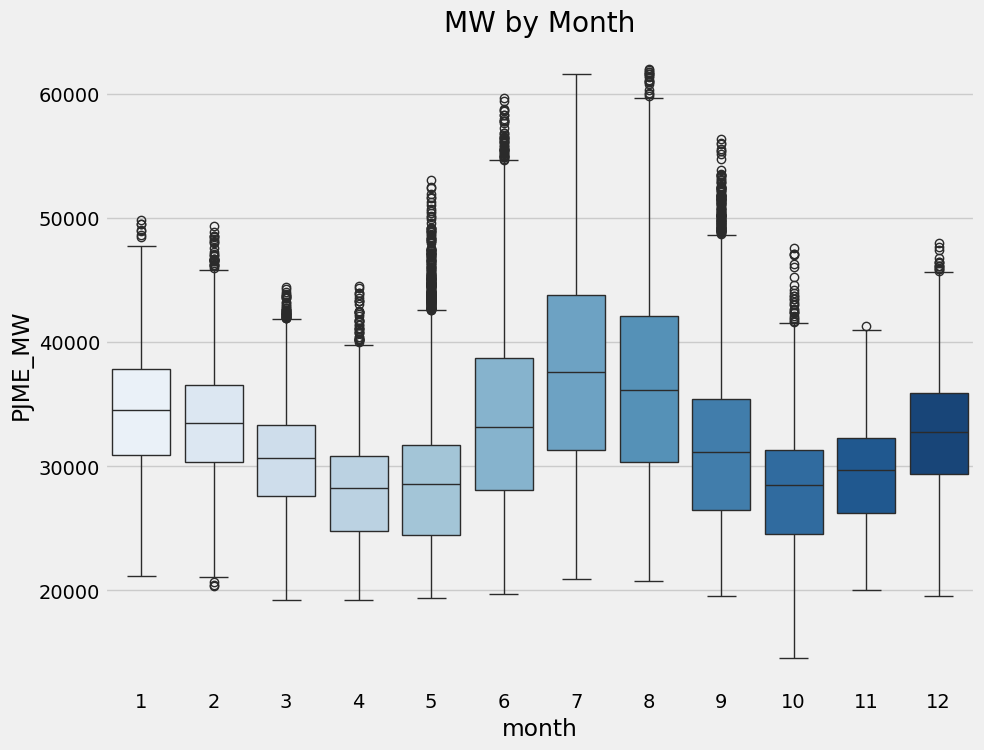

In [12]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)
print(df.head())

# Visualize Load by Hour (Interpreting Daily Cycles)
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()

# Visualize Load by Month (Interpreting Seasonal Cycles)
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

## 3. Train / Test Split
We cut the data at a specific date to evaluate how well our model forecasts future data it hasn't seen. We'll split at `2015-01-01`.

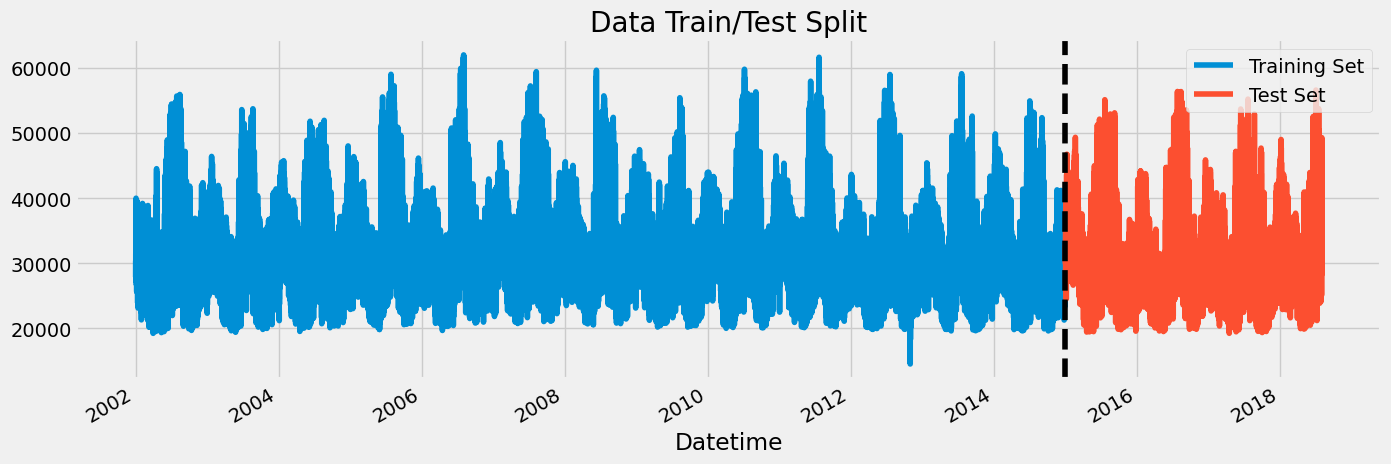

In [13]:
split_date = '2015-01-01'
train = df.loc[df.index < split_date]
test = df.loc[df.index >= split_date]

fig, ax = plt.subplots(figsize=(15, 5))
train['PJME_MW'].plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test['PJME_MW'].plot(ax=ax, label='Test Set')
ax.axvline(split_date, color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

## 4. Build and Train Model
We'll use XGBoost (Extreme Gradient Boosting), a powerful algorithm for tabular and time-series data.

In [14]:
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32605.13970	validation_1-rmse:31657.15729
[100]	validation_0-rmse:12584.35462	validation_1-rmse:11747.28803
[200]	validation_0-rmse:5837.33066	validation_1-rmse:5363.58554
[300]	validation_0-rmse:3923.28511	validation_1-rmse:4020.48045
[400]	validation_0-rmse:3447.54638	validation_1-rmse:3860.60088
[500]	validation_0-rmse:3288.19208	validation_1-rmse:3816.37862
[600]	validation_0-rmse:3206.55619	validation_1-rmse:3779.04119
[700]	validation_0-rmse:3153.61368	validation_1-rmse:3754.45684
[800]	validation_0-rmse:3114.34038	validation_1-rmse:3738.38209
[900]	validation_0-rmse:3084.39550	validation_1-rmse:3730.01893
[989]	validation_0-rmse:3059.85847	validation_1-rmse:3727.94591


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabete

## 5. Forecast and Evaluation
We generate predictions on the test set and visually compare them to the actual load.

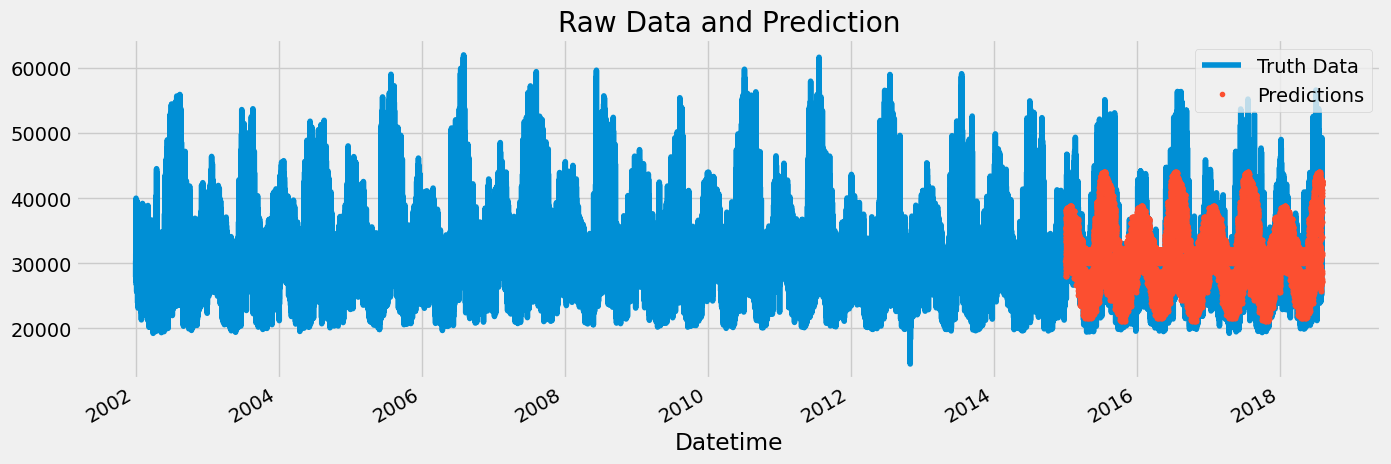

RMSE Score on Test set: 3726.80


date
2016-08-13    12879.484619
2016-08-14    12772.887207
2015-02-20    11186.031494
2016-09-09    10966.513102
2016-09-10    10889.102214
Name: error, dtype: float64

In [15]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)

# Visualize the forecast
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
plt.title('Raw Data and Prediction')
plt.show()

# Calculate Error Metrics
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

# Look at the worst predicted days
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(5)

## 6. Transformer Overload Prevention System
Now we simulate the "Protection" aspect. 

**Scenario**: We have a distribution transformer that serves this region. 
1. **Define Capacity**: We'll assume the transformer's rated capacity is `45,000 MW` (just for simulation purposes, slightly below the max peak).
2. **Logic**: If the *forecasted* load exceeds the `Safety Threshold` (e.g., 95% of capacity), we flag an alert.
3. **Action**: In a real system, this would trigger battery dispatch, demand response, or grid reconfiguration.

Transformer Capacity: 45000 MW
Safety Limit (95%): 42750.0 MW
Number of forecasted overload hours: 672

⚠️ ALERT: Potential Transformer Overload Detected for the following timestamps:
                     PJME_MW    prediction  overload_risk
Datetime                                                 
2015-06-24 18:00:00  43267.0  42757.031250           True
2015-06-24 19:00:00  42429.0  42757.031250           True
2015-06-24 20:00:00  40718.0  42757.031250           True
2015-06-30 13:00:00  38537.0  42820.750000           True
2015-06-30 14:00:00  39974.0  42965.027344           True
2015-06-30 15:00:00  40919.0  42965.027344           True
2015-06-30 16:00:00  41508.0  43005.910156           True
2015-06-30 17:00:00  41683.0  43355.238281           True
2015-06-30 18:00:00  41562.0  43455.363281           True
2015-06-30 19:00:00  40526.0  43455.363281           True


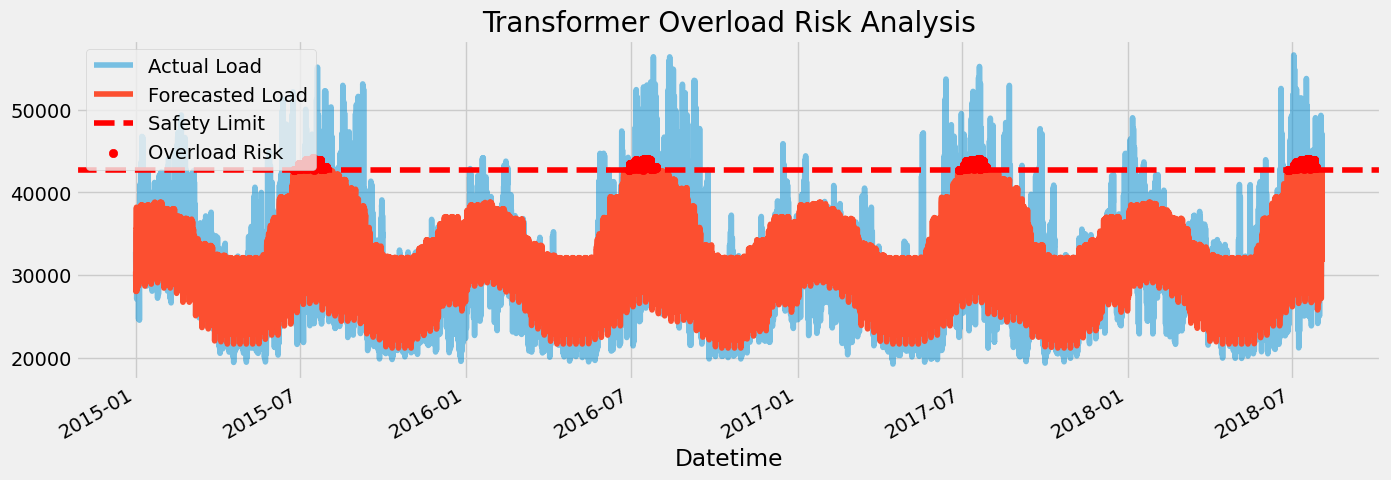

In [ ]:
# Define Transformer Constraints
TRANSFORMER_CAPACITY_MW = 45000
SAFETY_THRESHOLD_PERCENT = 0.95
SAFETY_LIMIT = TRANSFORMER_CAPACITY_MW * SAFETY_THRESHOLD_PERCENT

print(f"Transformer Capacity: {TRANSFORMER_CAPACITY_MW} MW")
print(f"Safety Limit (95%): {SAFETY_LIMIT} MW")

# Detect Overloads in Forecast
test['overload_risk'] = test['prediction'] > SAFETY_LIMIT

# Filter incidents
overload_incidents = test[test['overload_risk'] == True]

print(f"Number of forecasted overload hours: {len(overload_incidents)}")

if not overload_incidents.empty:
    print("\n⚠️ ALERT: Potential Transformer Overload Detected for the following timestamps:")
    print(overload_incidents[['PJME_MW', 'prediction', 'overload_risk']].head(10))
    
    # Visualize Warnings
    fig, ax = plt.subplots(figsize=(15, 5))
    test['PJME_MW'].plot(ax=ax, alpha=0.5, label='Actual Load')
    test['prediction'].plot(ax=ax, label='Forecasted Load')
    
    # Plot Red Zones
    ax.axhline(SAFETY_LIMIT, color='r', linestyle='--', label='Safety Limit')
    
    # Highlight overload points
    ax.scatter(overload_incidents.index, overload_incidents['prediction'], color='red', label='Overload Risk', zorder=5)
    
    ax.legend()
    plt.title('Transformer Overload Risk Analysis')
    plt.show()
else:
    print("✅ No transformer overloads predicted in the test period.")